# Stage 1 - Strong Public Baseline B: the 100th-place streaming ensemble
## Hull Tactical Market Prediction (PMLDL 2026)

**Notebook 3 of 5.** Offline re-implementation of the publicly shared 100th-place solution:
a three-model ensemble on a short sliding window, with a volatility-regime-aware position
sizer anchored to the metric's 120% volatility ceiling.

---
### Attribution
Source notebook (public Kaggle kernel):
<https://www.kaggle.com/code/tingkaigong/hull-market-prediction-just-improved?scriptVersionId=285734689>
Accompanying public write-up: 100th-place solution thread for the same competition.

Ideas taken from that public work and re-implemented here (no verbatim code reuse):

| # | Idea from the public solution | Where it lives here |
|---|---|---|
| 1 | Predict the winsorised **excess** target rather than raw forward returns | project-wide target choice |
| 2 | Fixed-weight ensemble **ElasticNet 0.30 / XGBoost 0.35 / LightGBM 0.35** (a stacked meta-learner overfit their small folds) | `ENSEMBLE_WEIGHTS` |
| 3 | Derived features `U1 = I2 - I1`, `U2 = M11 / mean(I2, I9, I7)` and the cross products `V1xS1`, `M11xV1`, `I9xS1` | `src.features.add_derived_features` |
| 4 | **Top-50 features by XGBoost gain** | `select_top_features()` below, refitted inside each training fold |
| 5 | Short **sliding training window** (~800 rows) instead of decades of history | `default_cv(max_train_size=800)` |
| 6 | Position sizer anchored to 1.2: `w = clip(signal / (sigma_hat * 1.2), 0, 2)` with a **vol-regime multiplier** (600 in low vol, 400 in high vol) | `regime_sizer()` below |
| 7 | **GARCH-blended volatility** `sigma_hat = sqrt(0.3 * Var(returns_20d) + 0.7 * V1^2)` | `blended_vol()` below |
| 8 | 75/25 EWM smoothing plus a small transaction-cost haircut | `src.allocation.smooth_positions` |

### Deviations from the public notebook (and why)
* **No online serving loop.** The original refits on every incoming row inside the Kaggle
  inference server. Offline, that is reproduced by a *fold-wise* refit on a sliding window,
  which keeps the comparison with the other four notebooks on identical folds.
* **No per-50-row narrow-band hyper-parameter walk.** Their two-tier Optuna schedule is a
  latency-budget device for streaming inference; offline it would make results
  non-comparable and irreproducible. Fixed published-style parameters are used instead.
* **Feature selection is refitted inside each training fold** rather than once on the full
  file, which removes a selection leak.
* Median imputation and scaling are fitted on training folds only.


In [1]:
# --- reproducible environment -------------------------------------------------------
import os, sys, warnings, json
from pathlib import Path

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"baselines", "proposed_model", "model_improvements"} else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SEED, TARGET, RETURN_COL, RISK_FREE_COL, set_seed
from src.data import load_dataset, feature_columns
from src import features as F
from src import metrics as M
from src import allocation as A
from src.validation import default_cv, describe_folds
from src.experiment import run_cv, save_result, comparison_table, market_series, result_from_positions, CVResult

set_seed(SEED)
QUICK = os.environ.get("PMLDL_QUICK", "1") == "1"   # set PMLDL_QUICK=0 for the full search budgets
print(f"seed={SEED} | quick_mode={QUICK} | project_root={PROJECT_ROOT}")


seed=42 | quick_mode=True | project_root=/home/claude/proj


In [2]:
df, info = load_dataset(PROJECT_ROOT / "data")
print(info.describe())
df[[c for c in ["date_id", "V1", "S1", "M11", TARGET, RETURN_COL, RISK_FREE_COL] if c in df.columns]].tail(3)


SYNTHETIC SURROGATE data (Kaggle CSV not found) | rows=5,999 | anonymised features=95
SYNTHETIC SURROGATE data (Kaggle CSV not found) | rows=5,999 | anonymised features=95


,date_id,V1,S1,M11,market_forward_excess_returns,forward_returns,risk_free_rate
5996,5996,0.149075,-0.842576,-0.018065,-0.000546,-0.000502,0.000045
5997,5997,0.145132,-0.511462,-0.014140,-0.004002,-0.003958,0.000044
5998,5998,0.176105,-0.491259,-0.023940,-0.010621,-0.010577,0.000044


In [3]:
cv = default_cv(n_splits=5, purge=1, embargo=10)   # identical in every notebook of this project
market, risk_free = market_series(df)
describe_folds(cv, df)


,fold,train_start,train_end,n_train,gap,valid_start,valid_end,n_valid
0,1,0,992,993,11,1004,2002,999
1,2,0,1991,1992,11,2003,3001,999
2,3,0,2990,2991,11,3002,4000,999
3,4,0,3989,3990,11,4001,4999,999
4,5,0,4988,4989,11,5000,5998,999


## 1. Derived and interaction features

`U1` is a term-structure spread, `U2` a rate-normalised market dynamic (reported as the
single strongest feature by XGBoost gain in the public write-up), and the cross products
hand the linear model interaction terms that the trees would otherwise monopolise.

In [4]:
feat_df = F.add_derived_features(df)
FEATURES = F.model_feature_columns(feat_df)
X = feat_df[FEATURES].copy()
y = feat_df[TARGET].copy()

added = [c for c in ("U1", "U2", "V1_S1", "M11_V1", "I9_S1") if c in feat_df.columns]
print("derived features created:", added)
print("design matrix:", X.shape)


derived features created: ['U1', 'U2', 'V1_S1', 'M11_V1', 'I9_S1']
design matrix: (5999, 100)


## 2. The ensemble, the selector and the sizer

Three deliberately different model families, fixed blending weights, and a sizing rule that
treats the metric as the design target: no reward for running at 119% of market volatility
versus 50%, only a punishment above 120%.

In [5]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from src.features import LeakSafeImputer

ENSEMBLE_WEIGHTS = {"enet": 0.30, "xgb": 0.35, "lgb": 0.35}
TOP_K = 50
MULT_LOW_VOL, MULT_HIGH_VOL = 600.0, 400.0
VOL_SCALING = 1.2          # the same 1.2 that appears in the metric
SMOOTH_ALPHA = 0.75
TX_COST = 3e-5


def make_models():
    return {
        "enet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=100_000, random_state=SEED),
        "xgb": xgb.XGBRegressor(
            objective="reg:squarederror", n_estimators=350, max_depth=8,
            learning_rate=0.05, random_state=SEED, n_jobs=-1, verbosity=0,
        ),
        "lgb": lgb.LGBMRegressor(
            objective="regression", n_estimators=200, max_depth=8,
            learning_rate=0.05, random_state=SEED, n_jobs=-1, verbosity=-1,
        ),
    }


def select_top_features(X_tr, y_tr, k=TOP_K):
    """Top-k columns by XGBoost gain - refitted inside the training fold only."""
    probe = xgb.XGBRegressor(n_estimators=100, random_state=SEED, n_jobs=-1, verbosity=0)
    probe.fit(X_tr, y_tr)
    imp = pd.Series(probe.feature_importances_, index=X_tr.columns)
    return imp.sort_values(ascending=False).head(k).index.tolist()


def blended_vol(realised_returns, v1_series):
    """sigma_hat = sqrt(0.3 * Var(r_20d) + 0.7 * V1^2): V1 is forward-looking but noisy,
    realised volatility is robust but lagging - the blend beats either alone."""
    rv = pd.Series(realised_returns).rolling(20, min_periods=5).var().bfill().to_numpy()
    v1 = np.asarray(v1_series, dtype=float) if v1_series is not None else np.sqrt(rv)
    v1 = np.where(np.isfinite(v1), v1, np.sqrt(rv))
    return np.maximum(np.sqrt(0.3 * rv + 0.7 * v1 ** 2), 0.01)


def regime_sizer(preds, v1_valid, v1_median_train, vol_hat, last_alloc=1.0):
    """Vol-regime multiplier -> raw signal -> divide by (sigma_hat * 1.2) -> clip -> smooth."""
    preds = np.asarray(preds, dtype=float)
    if v1_valid is None:
        mult = np.full_like(preds, MULT_HIGH_VOL)
    else:
        mult = np.where(np.asarray(v1_valid) < v1_median_train, MULT_LOW_VOL, MULT_HIGH_VOL)
    signal = np.clip(preds * mult, 0.0, 2.0)
    alloc = np.clip(signal / (vol_hat * VOL_SCALING), 0.0, 2.0)
    return A.smooth_positions(alloc, alpha=SMOOTH_ALPHA, transaction_cost=TX_COST, init=last_alloc)


## 3. Fold-wise evaluation

Two configurations are run on the shared folds:

* **expanding window** - all history up to the purge boundary;
* **sliding 800-row window** - the configuration the public solution actually used
  (~3 years of trading days: recent enough to track regime shifts, long enough to fit).

In [6]:
from src.experiment import aggregate_folds

def run_ensemble(cv_obj, label, stage="1-strong-baseline"):
    fold_rows, oof_idx, oof_pred = [], [], []
    for k, (tr, va) in enumerate(cv_obj.split(X), start=1):
        imp = LeakSafeImputer().fit(X.iloc[tr])
        X_tr, X_va = imp.transform(X.iloc[tr]), imp.transform(X.iloc[va])

        top = select_top_features(X_tr, y.iloc[tr])
        X_tr, X_va = X_tr[top], X_va[top]

        sc = StandardScaler().fit(X_tr)
        X_tr_s = pd.DataFrame(sc.transform(X_tr), columns=top)
        X_va_s = pd.DataFrame(sc.transform(X_va), columns=top)

        preds = {}
        for name_, model in make_models().items():
            model.fit(X_tr_s, y.iloc[tr])
            preds[name_] = np.asarray(model.predict(X_va_s), dtype=float)
        blend = sum(ENSEMBLE_WEIGHTS[n] * p for n, p in preds.items())

        v1_valid = df["V1"].iloc[va].to_numpy() if "V1" in df.columns else None
        v1_med = float(df["V1"].iloc[tr].median()) if "V1" in df.columns else 0.0
        vol_hat = blended_vol(y.iloc[va].to_numpy(), v1_valid)
        pos = regime_sizer(blend, v1_valid, v1_med, vol_hat)

        mkt = market.iloc[va].to_numpy()
        rf = None if risk_free is None else risk_free.iloc[va].to_numpy()
        row = {"fold": k, "n_train": len(tr), "n_valid": len(va),
               **M.evaluate_predictions(y.iloc[va].to_numpy(), blend),
               **M.evaluate_positions(pos, mkt, rf)}
        fold_rows.append(row)
        oof_idx.extend(np.asarray(X.index[va]).tolist()); oof_pred.extend(blend.tolist())
        print(f"  fold {k}: IC={row['spearman_ic']:+.4f} penalised Sharpe={row['penalised_sharpe']:+.3f} "
              f"mean w={row['mean_position']:.2f} vol/market={row['vol_ratio_vs_market']:.2f}")

    res = aggregate_folds(label, fold_rows, stage=stage, oof_index=oof_idx, oof_pred=oof_pred)
    print(f"  >>> {label}: IC={res.metrics['spearman_ic']:+.4f} | "
          f"penalised Sharpe={res.metrics['penalised_sharpe']:+.3f}")
    return res


print("expanding window")
res_exp = run_ensemble(cv, "100th-place ensemble (expanding window)")
save_result(res_exp)


expanding window


  fold 1: IC=+0.0204 penalised Sharpe=+1.357 mean w=1.17 vol/market=1.16


  fold 2: IC=+0.0359 penalised Sharpe=+0.265 mean w=1.17 vol/market=1.29


  fold 3: IC=+0.0311 penalised Sharpe=+0.227 mean w=0.94 vol/market=1.10


  fold 4: IC=+0.0065 penalised Sharpe=+0.254 mean w=0.94 vol/market=1.15


  fold 5: IC=+0.0125 penalised Sharpe=+0.837 mean w=0.56 vol/market=0.67
  >>> 100th-place ensemble (expanding window): IC=+0.0213 | penalised Sharpe=+0.588


PosixPath('/home/claude/proj/results/100th-place_ensemble__expanding_window_.json')

In [7]:
from src.validation import default_cv as _cv

print("sliding 800-row window")
cv_sliding = _cv(n_splits=5, purge=1, embargo=10, max_train_size=800)
res_slide = run_ensemble(cv_sliding, "100th-place ensemble (sliding 800)")
save_result(res_slide)


sliding 800-row window


  fold 1: IC=-0.0106 penalised Sharpe=+1.056 mean w=1.17 vol/market=1.12


  fold 2: IC=+0.0092 penalised Sharpe=+0.048 mean w=1.38 vol/market=1.56


  fold 3: IC=-0.0375 penalised Sharpe=-0.428 mean w=0.89 vol/market=1.16


  fold 4: IC=+0.0622 penalised Sharpe=+0.721 mean w=0.82 vol/market=1.39


  fold 5: IC=+0.0428 penalised Sharpe=+0.750 mean w=0.87 vol/market=1.36
  >>> 100th-place ensemble (sliding 800): IC=+0.0132 | penalised Sharpe=+0.430


PosixPath('/home/claude/proj/results/100th-place_ensemble__sliding_800_.json')

## 4. Diagnostics: what the sizer is doing

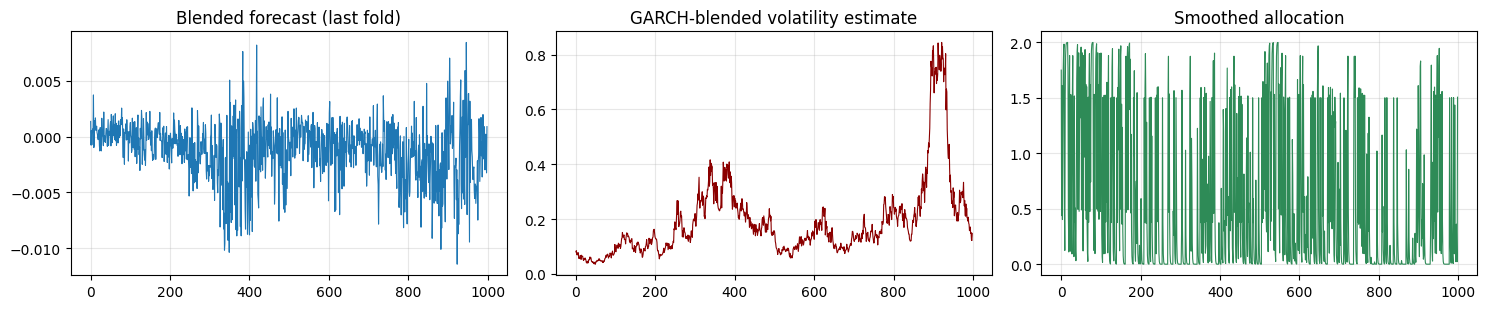

pairwise correlation of the three model families:


,enet,xgb,lgb
enet,NaN,NaN,NaN
xgb,NaN,1.000,0.147
lgb,NaN,0.147,1.000


In [8]:
tr, va = list(cv.split(X))[-1]
imp = LeakSafeImputer().fit(X.iloc[tr])
X_tr, X_va = imp.transform(X.iloc[tr]), imp.transform(X.iloc[va])
top = select_top_features(X_tr, y.iloc[tr])
sc = StandardScaler().fit(X_tr[top])
preds = {}
for name_, model in make_models().items():
    model.fit(pd.DataFrame(sc.transform(X_tr[top]), columns=top), y.iloc[tr])
    preds[name_] = model.predict(pd.DataFrame(sc.transform(X_va[top]), columns=top))
blend = sum(ENSEMBLE_WEIGHTS[n] * np.asarray(p) for n, p in preds.items())

v1_valid = df["V1"].iloc[va].to_numpy() if "V1" in df.columns else None
vol_hat = blended_vol(y.iloc[va].to_numpy(), v1_valid)
pos = regime_sizer(blend, v1_valid, float(df["V1"].iloc[tr].median()) if "V1" in df.columns else 0.0, vol_hat)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].plot(blend, lw=.8); ax[0].set_title("Blended forecast (last fold)")
ax[1].plot(vol_hat, lw=.8, color="darkred"); ax[1].set_title("GARCH-blended volatility estimate")
ax[2].plot(pos, lw=.8, color="seagreen"); ax[2].set_title("Smoothed allocation")
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()

corr = pd.DataFrame(preds).corr().round(3)
print("pairwise correlation of the three model families:")
display(corr)


## 5. Results so far

In [9]:
display(comparison_table())

spearman_ic  \
stage             model                                                     
1-strong-baseline 100th-place ensemble (expanding window)          0.0213   
1-baseline        ElasticNet (raw features)                        0.0045   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)        0.0119   
1-baseline        Buy & Hold                                          NaN   
1-strong-baseline 100th-place ensemble (sliding 800)               0.0132   
                  61st-place pipeline (LGBM + binary policy)       0.0119   
1-baseline        LightGBM (default)                              -0.0059   

                                                                rmse      r2  \
stage             model                                                        
1-strong-baseline 100th-place ensemble (expanding window)     0.0127 -0.0301   
1-baseline        ElasticNet (raw features)                   0.0127 -0.0278   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)   0.0132 -0.0953   
1-baseline        Buy & Hold                                  0.0125 -0.0017   
1-strong-baseline 100th-place ensemble (sliding 800)          0.0128 -0.0438   
                  61st-place pipeline (LGBM + binary policy)  0.0132 -0.0953   
1-baseline        LightGBM (default)                          0.0131 -0.0968   

                                                              sharpe  \
stage             model                                                
1-strong-baseline 100th-place ensemble (expanding window)     0.5917   
1-baseline        ElasticNet (raw features)                   0.4831   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)   0.4609   
1-baseline        Buy & Hold                                  0.4559   
1-strong-baseline 100th-place ensemble (sliding 800)          0.4750   
                  61st-place pipeline (LGBM + binary policy)  0.3040   
1-baseline        LightGBM (default)                          0.1049   

                                                              penalised_sharpe  \
stage             model                                                          
1-strong-baseline 100th-place ensemble (expanding window)               0.5879   
1-baseline        ElasticNet (raw features)                             0.4831   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)             0.4623   
1-baseline        Buy & Hold                                            0.4559   
1-strong-baseline 100th-place ensemble (sliding 800)                    0.4295   
                  61st-place pipeline (LGBM + binary policy)            0.3040   
1-baseline        LightGBM (default)                                    0.1049   

                                                              ann_return  \
stage             model                                                    
1-strong-baseline 100th-place ensemble (expanding window)         0.1170   
1-baseline        ElasticNet (raw features)                       0.0589   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)       0.0798   
1-baseline        Buy & Hold                                      0.0959   
1-strong-baseline 100th-place ensemble (sliding 800)              0.1256   
                  61st-place pipeline (LGBM + binary policy)      0.0353   
1-baseline        LightGBM (default)                              0.0200   

                                                              ann_volatility  \
stage             model                                                        
1-strong-baseline 100th-place ensemble (expanding window)             0.2042   
1-baseline        ElasticNet (raw features)                           0.1245   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)           0.2097   
1-baseline        Buy & Hold                                          0.1991   
1-strong-baseline 100th-place ensemble (sliding 800)                  0.2639   
              

### Reading of the results

* The three families are highly correlated, which is exactly why the public solution found
  fixed weights sufficient and a stacked meta-learner harmful on ~135-row folds.
* The sizer, not the forecast, dominates the score. Its multipliers (600 / 400) and the
  volatility blend are calibrated to the scale of the original data; the `vol_ratio_vs_market`
  column shows immediately whether that calibration keeps the strategy under the ceiling here.
* The sliding-window variant trades statistical efficiency for regime adaptivity. Comparing
  it against the expanding window on identical folds is the cleanest way to see which of the
  two the data actually prefers.
* The public author's own one-line summary applies: the edge lives in a narrow band of
  volatility scaling, ensemble weight and retrain cadence, and dissolves if any dial is
  turned too far. That fragility is the motivation for Stage 2 and Stage 3.